In [49]:
#Importing libraries
import pyarrow.parquet as pq
import polars as pl
import os
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap

c:\Users\Italo\anaconda3\envs\cibersec2_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
#Carregando dados na memória
default_path = "C:/Users/Italo/Desktop/UERJ/2026.1/cibersecurity/cybersecurity-uerj-2026-1"
parquet_path = os.path.join(default_path, "final-project/db/dnn.parquet")
print(parquet_path)
tabela_arrow = pq.read_table(parquet_path)
df = pl.from_arrow(tabela_arrow)

C:/Users/Italo/Desktop/UERJ/2026.1/cibersecurity/cybersecurity-uerj-2026-1\final-project/db/dnn.parquet


In [3]:
df.show(20)

frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.file_data,http.content_length,http.request.uri.query,http.request.method,http.referer,http.request.full_uri,http.request.version,http.response,http.tls_port,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.dstport,tcp.flags,tcp.flags.ack,tcp.len,tcp.options,tcp.payload,tcp.seq,tcp.srcport,udp.port,udp.stream,udp.time_delta,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,dns.retransmission,dns.retransmit_request,dns.retransmit_request_in,mqtt.conack.flags,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msg_decoded_as,mqtt.msg,mqtt.msgtype,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
str,str,str,str,f64,f64,str,f64,f64,f64,f64,str,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,str,f64,f64,str,str,f64,f64,f64,f64,f64,i64,str
""" 2021 11:44:10.081753000 ""","""192.168.0.128""","""192.168.0.101""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,1.0,3.1533e9,47892.0,0.0,0.0,0.0,1.0,64855.0,18.0,1.0,0.0,"""020405b40101040201030307""","""0""",0.0,"""1883.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
""" 2021 11:44:10.162218000 ""","""192.168.0.101""","""192.168.0.128""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,1.0,3.44794516e8,16077.0,0.0,0.0,0.0,0.0,1883.0,24.0,1.0,14.0,"""0""","""100c00044d5154540402003c0000""",1.0,"""64855.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""",1.0,2.0,16.0,12.0,0.0,"""0""",1.0,4.0,"""MQTT""","""0""",0.0,4.0,0.0,0.0,0.0,0,"""Normal"""
""" 2021 11:44:10.162271000 ""","""192.168.0.128""","""192.168.0.101""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,15.0,3.1533e9,62675.0,0.0,0.0,0.0,0.0,64855.0,16.0,1.0,0.0,"""0""","""0""",1.0,"""1883.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
""" 2021 11:44:10.162641000 ""","""192.168.0.128""","""192.168.0.101""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,15.0,3.1533e9,54469.0,0.0,0.0,0.0,0.0,64855.0,24.0,1.0,4.0,"""0""","""20020000""",1.0,"""1883.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0x00000000""",0.0,0.0,32.0,2.0,0.0,"""0""",2.0,0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
""" 2021 11:44:10.166132000 ""","""192.168.0.101""","""192.168.0.128""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,5.0,3.4479452e8,53812.0,0.0,0.0,0.0,0.0,1883.0,24.0,1.0,41.0,"""0""","""3027001854656d7065726174757265…",15.0,"""64855.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,48.0,39.0,0.0,"""32342e36382037362e34320d0a""",3.0,0.0,"""0""","""Temperature_and_Humidity""",24.0,0.0,0.0,0.0,0.0,0,"""Normal"""
""" 2021 11:44:10.166159000 ""","""192.168.0.128""","""192.168.0.101""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,56.0,3.1533e9,62630.0,0.0,0.0,0.0,0.0,64855.0,16.0,1.0,0.0,"""0""","""0""",5.0,"""1883.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
""" 2021 11:44:10.166968000 ""","""192.168.0.101""","""192.168.0.128""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""

In [41]:
#Dropando colunas do dataset
drop_columns = [
    "frame.time", 
    "ip.src_host", 
    "ip.dst_host", 
    "arp.dst.proto_ipv4", 
    "arp.opcode", 
    "arp.hw.size", 
    "arp.dst.proto_ipv4", 
    "arp.src.proto_ipv4", 
    "icmp.checksum", 
    "icmp.seq_le",
    "icmp.transmit_timestamp", 
    "icmp.unused", 
    "http.file_data", #Ponderar se deixar ou não
    "http.request.full_uri",
    "http.referer",
    "http.request.uri.query",
    "http.request.version",
    "http.tls_port",
    "tcp.dstport",
    "tcp.options",
    "tcp.srcport",
    "udp.port",
    "udp.time_delta",
    "dns.qry.type",
    "dns.retransmission",
    "mqtt.conack.flags",
    "mqtt.msg_decoded_as",
    "mqtt.msg",
    "mqtt.topic",
    "dns.qry.name.len",
    "mqtt.protoname"
]


df = df.drop(drop_columns)
df.head(20)


http.content_length,http.request.method,http.response,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.flags,tcp.flags.ack,tcp.len,tcp.payload,tcp.seq,udp.stream,dns.qry.name,dns.qry.qu,dns.retransmit_request,dns.retransmit_request_in,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str
0.0,"""0.0""",0.0,1.0,3.1533e9,47892.0,0.0,0.0,0.0,1.0,18.0,1.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,1.0,3.44794516e8,16077.0,0.0,0.0,0.0,0.0,24.0,1.0,14.0,"""100c00044d5154540402003c0000""",1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,16.0,12.0,1.0,4.0,0.0,4.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,15.0,3.1533e9,62675.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,15.0,3.1533e9,54469.0,0.0,0.0,0.0,0.0,24.0,1.0,4.0,"""20020000""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,5.0,3.4479452e8,53812.0,0.0,0.0,0.0,0.0,24.0,1.0,41.0,"""3027001854656d7065726174757265…",15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48.0,39.0,3.0,0.0,24.0,0.0,0.0,0.0,0.0,0,"""Normal"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,"""0.0""",0.0,6.0,3.44794521e8,62615.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",59.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,1.0,1.0455e9,35755.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,15.0,3.2943e9,35748.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""


In [22]:
df.group_by("mqtt.protoname", "Attack_label").agg(pl.len().alias("count")).sort("count", descending=True)


mqtt.protoname,Attack_label,count
str,i64,u32
"""0""",0,1532608
"""0.0""",1,603558
"""MQTT""",0,83035


Mapping labels to integers (http.request.method)

In [42]:
mapping_rm = {"0.0": 0.0,
                  "0": 0.0,
                  "GET": 1.0,
                  "POST": 2.0,
                  "TRACE": 3.0,
                  "OPTIONS": 4.0,
                  "PROPFIND": 5.0,
                  "PUT": 6.0,
                  "SEARCH": 7.0}

keys = pl.Series(mapping_rm.keys())
values = pl.Series(mapping_rm.values())

df = df.with_columns(
    pl.col("http.request.method").replace_strict(keys, values, default=0)
)

df.show(20)

http.content_length,http.request.method,http.response,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.flags,tcp.flags.ack,tcp.len,tcp.payload,tcp.seq,udp.stream,dns.qry.name,dns.qry.qu,dns.retransmit_request,dns.retransmit_request_in,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str
0.0,0.0,0.0,1.0,3.1533e9,47892.0,0.0,0.0,0.0,1.0,18.0,1.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,1.0,3.44794516e8,16077.0,0.0,0.0,0.0,0.0,24.0,1.0,14.0,"""100c00044d5154540402003c0000""",1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,16.0,12.0,1.0,4.0,0.0,4.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,15.0,3.1533e9,62675.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,15.0,3.1533e9,54469.0,0.0,0.0,0.0,0.0,24.0,1.0,4.0,"""20020000""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,5.0,3.4479452e8,53812.0,0.0,0.0,0.0,0.0,24.0,1.0,41.0,"""3027001854656d7065726174757265…",15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48.0,39.0,3.0,0.0,24.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,56.0,3.1533e9,62630.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,5.0,3.4479452e8,5264.0,1.0,0.0,0.0,0.0,25.0,1.0,2.0,"""e000""",56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,224.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,59.0,3.1533e9,62626.0,1.0,0.0,0.0,0.0,17.0,1.0,0.0,"""0""",5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,0.0,0.0,158.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""


Translating labels to float (tcp.payload)

In [43]:

df = df.with_columns(
    pl.when(pl.col("tcp.payload") != "0")
      .then(pl.lit(0))
      .otherwise(pl.lit(1))
      .cast(pl.Float64)
      .alias("tcp.payload")
)


## One Hot Encoding Attack_type column

In [46]:
df.count()

http.content_length,http.request.method,http.response,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.flags,tcp.flags.ack,tcp.len,tcp.payload,tcp.seq,udp.stream,dns.qry.name,dns.qry.qu,dns.retransmit_request,dns.retransmit_request_in,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201,2219201


In [ ]:
df=df.to_dummies("Attack_type")
df.drop("Attack_type")


###  Parte de normalização dos dados do dataset (Rodar sem normalização primeiro pra ver como que tá)


In [ ]:
#Normalizar coluna de content_length do HTTP

#Features importantes: 
# - http.request.method
# - http.content_length 
# - tcp.ack



# Min-Max http.content_length
df = df.with_columns(
    ((pl.col("http.content_length") - pl.col("http.content_length").min()) / 
     (pl.col("http.content_length").max() - pl.col("http.content_length").min())).alias("http.content_length_normalized")
)


# Min-Max http.content_length
df = df.with_columns(
    ((pl.col("tcp.ack") - pl.col("tcp.ack").min()) / 
     (pl.col("tcp.ack").max() - pl.col("tcp.ack").min())).alias("tcp.ack_normalized")
)

# Min-Max http.content_length
df = df.with_columns(
    ((pl.col("tcp.ack_raw") - pl.col("tcp.ack_raw").min()) / 
     (pl.col("tcp.ack_raw").max() - pl.col("tcp.ack_raw").min())).alias("tcp.ack_raw_normalized")
)

# Min-Max http.content_length
df = df.with_columns(
    ((pl.col("tcp.checksum") - pl.col("tcp.checksum").min()) / 
     (pl.col("tcp.checksum").max() - pl.col("tcp.checksum").min())).alias("tcp.checksum_normalized")
)


df = df.with_columns(
    ((pl.col("tcp.len") - pl.col("tcp.len").min()) / 
     (pl.col("tcp.len").max() - pl.col("tcp.len").min())).alias("tcp.checksum_normalized")
)




df = df.with_columns(
    ((pl.col("dns.qry.name") - pl.col("dns.qry.name").min()) / 
     (pl.col("dns.qry.name").max() - pl.col("dns.qry.name").min())).alias("tcp.checksum_normalized")
)






# 4. (Opcional) Se você precisar devolver o resultado para o PyArrow:
tabela_arrow_final = df_normalizado.to_arrow()

# 5. Salvar o arquivo final de volta em Parquet usando o PyArrow
pq.write_table(tabela_arrow_final, os.path.join("db/seu_arquivo_normalizado.parquet"))

print("Processamento concluído com sucesso!")
print(df_normalizado.head()) # Exibe as primeiras 5 linhas do resultado

C:/Users/Italo/Desktop/UERJ/2026.1/cibersecurity/cybersecurity-uerj-2026-1\final-project/db/dnn.parquet
Processamento concluído com sucesso!
shape: (5, 64)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ frame.tim ┆ ip.src_ho ┆ ip.dst_ho ┆ arp.dst.p ┆ … ┆ mbtcp.uni ┆ Attack_la ┆ Attack_ty ┆ http.con │
│ e         ┆ st        ┆ st        ┆ roto_ipv4 ┆   ┆ t_id      ┆ bel       ┆ pe        ┆ tent_len │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ gth_norm │
│ str       ┆ str       ┆ str       ┆ str       ┆   ┆ f64       ┆ i64       ┆ str       ┆ alized   │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2021 11:4 ┆ 192.168.0 ┆ 192.168.0 

In [13]:
df

http.content_length,http.request.method,http.response,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.flags,tcp.flags.ack,tcp.len,tcp.payload,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.retransmit_request,dns.retransmit_request_in,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msgtype,mqtt.proto_len,mqtt.protoname,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,str
0.0,"""0.0""",0.0,1.0,3.1533e9,47892.0,0.0,0.0,0.0,1.0,18.0,1.0,0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,1.0,3.44794516e8,16077.0,0.0,0.0,0.0,0.0,24.0,1.0,14.0,"""100c00044d5154540402003c0000""",0.0,"""0""",0.0,0.0,0.0,1.0,2.0,16.0,12.0,1.0,4.0,"""MQTT""",0.0,4.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,15.0,3.1533e9,62675.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,15.0,3.1533e9,54469.0,0.0,0.0,0.0,0.0,24.0,1.0,4.0,"""20020000""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,32.0,2.0,2.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,5.0,3.4479452e8,53812.0,0.0,0.0,0.0,0.0,24.0,1.0,41.0,"""3027001854656d7065726174757265…",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,48.0,39.0,3.0,0.0,"""0""",24.0,0.0,0.0,0.0,0.0,0,"""Normal"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,"""0.0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,0.0,0.0,0.0,0.0,1,"""DDoS_ICMP"""
0.0,"""0.0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,0.0,0.0,0.0,0.0,1,"""DDoS_ICMP"""
0.0,"""0.0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,0.0,0.0,0.0,0.0,1,"""DDoS_ICMP"""


### Rodando o algoritmo XGBoost

--- Primeiras linhas do DataFrame Polars (X_pl) ---
shape: (3, 31)
┌────────────┬────────────┬───────────┬─────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ http.conte ┆ http.reque ┆ http.resp ┆ tcp.ack ┆ … ┆ mqtt.ver ┆ mbtcp.len ┆ mbtcp.tra ┆ mbtcp.uni │
│ nt_length  ┆ st.method  ┆ onse      ┆ ---     ┆   ┆ ---      ┆ ---       ┆ ns_id     ┆ t_id      │
│ ---        ┆ ---        ┆ ---       ┆ f64     ┆   ┆ f64      ┆ f64       ┆ ---       ┆ ---       │
│ f64        ┆ f64        ┆ f64       ┆         ┆   ┆          ┆           ┆ f64       ┆ f64       │
╞════════════╪════════════╪═══════════╪═════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ 0.0        ┆ 0.0        ┆ 0.0       ┆ 1.0     ┆ … ┆ 0.0      ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ 0.0        ┆ 0.0        ┆ 0.0       ┆ 1.0     ┆ … ┆ 4.0      ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ 0.0        ┆ 0.0        ┆ 0.0       ┆ 15.0    ┆ … ┆ 0.0      ┆ 0.0       ┆ 0.0       ┆ 0.0       │
└────────────┴──────────

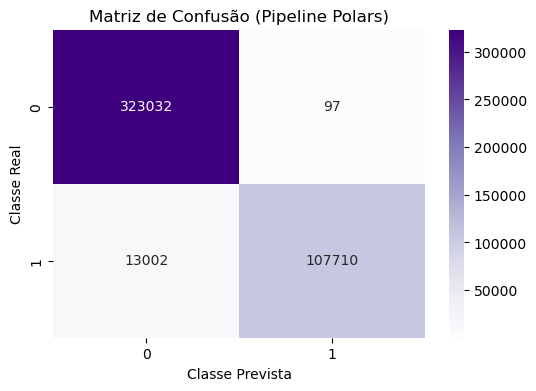

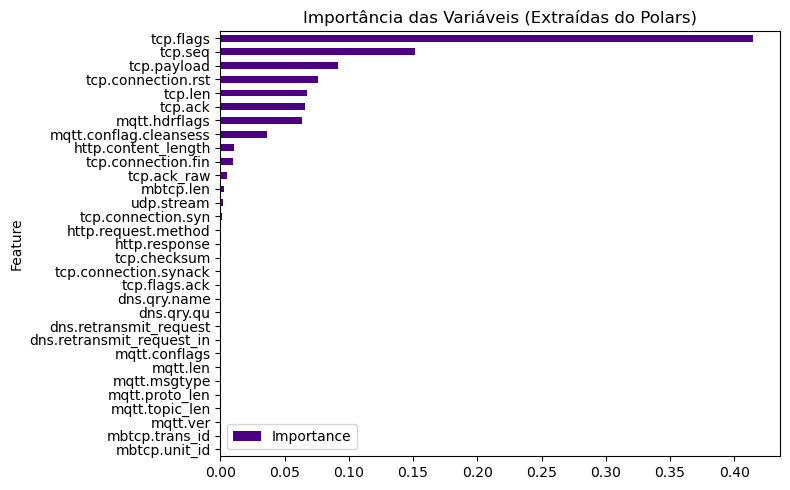

In [51]:


# =====================================================================
# 1. CARREGAMENTO E ESTRUTURAÇÃO DOS DADOS COM POLARS
# =====================================================================
# Importando dados de exemplo para o formato Polars

# Criando o DataFrame principal no Polars
X_pl = df.drop("Attack_label", "Attack_type")
y_pl = pl.Series("target", df["Attack_label"])



print("--- Primeiras linhas do DataFrame Polars (X_pl) ---")
print(X_pl.head(3))

# =====================================================================
# 2. DIVISÃO EM TREINO E TESTE
# =====================================================================
# Como o train_test_split do scikit-learn lida melhor com arrays numéricos,
# passamos os dados convertendo-os para NumPy de forma performática.
X_train, X_test, y_train, y_test = train_test_split(
    X_pl.to_numpy(),
    y_pl.to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=y_pl.to_numpy(),
)

# =====================================================================
# 3. CONFIGURAÇÃO E TREINAMENTO DO XGBOOST
# =====================================================================
modelo = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss",
)

# Treinando o modelo
modelo.fit(X_train, y_train)
print("\n[INFO] Modelo XGBoost treinado com sucesso utilizando Polars!")

# =====================================================================
# 4. PREVISÕES E AVALIAÇÃO
# =====================================================================
y_pred = modelo.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"\nAcurácia Geral: {acuracia:.2%}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

# =====================================================================
# 5. VISUALIZAÇÃO GRÁFICA
# =====================================================================
# Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Purples",  # Só para diferenciar do padrão do pandas
    #xticklabels=df.target_names,
    #yticklabels=df.target_names,
)
plt.title("Matriz de Confusão (Pipeline Polars)")
plt.ylabel("Classe Real")
plt.xlabel("Classe Prevista")
plt.show()

# Importância das Features (mapeando os nomes das colunas originais do Polars)
plt.figure(figsize=(8, 5))
importances = modelo.feature_importances_
features = X_pl.columns

# Criando um gráfico de barras ordenado
pl.DataFrame({"Feature": features, "Importance": importances}).sort(
    "Importance", descending=True
).to_pandas().plot.barh(x="Feature", y="Importance", ax=plt.gca(), color="indigo")

plt.title("Importância das Variáveis (Extraídas do Polars)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()